In [1]:
import os
import re
import pickle
import datetime
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.collections import LineCollection
from pathlib import Path
import scipy.io as sio
import pandas as pd

# ─────────────────────────────────────────────────────────────────
# Default paths
# ─────────────────────────────────────────────────────────────────
BPOD_SESSION_DATA = Path("/var/home/almogmeir/Documents/M.Sc/Project/BPODData/NPC1/maze_pairs_fix/Session Data")
OUTPUTS_ROOT = Path("/var/home/almogmeir/Documents/GitHub/NaviGraph/examples/dual_root_tree/resources/outputs")
RESOURCES = Path("/var/home/almogmeir/Documents/GitHub/NaviGraph/examples/dual_root_tree/resources")


# ─────────────────────────────────────────────────────────────────
# Session date helpers
# ─────────────────────────────────────────────────────────────────
def folder_to_bpod_date(folder_name):
    p = folder_name.split('_')
    return f"{p[2]}{p[1]}{p[0]}"

def folder_to_resource_key(folder_name):
    p = folder_name.split('_')
    return f"{p[2]}_{p[1]}_{p[0]}"

def find_mat_file(folder_name):
    date_str = folder_to_bpod_date(folder_name)
    candidates = list(BPOD_SESSION_DATA.glob(f'*{date_str}*.mat'))
    subfolder = BPOD_SESSION_DATA / folder_name
    if subfolder.is_dir():
        candidates += list(subfolder.glob(f'*{date_str}*.mat'))
    return sorted(candidates)[0] if candidates else None

def get_port_map(folder_name):
    """R55 ↔ R59 swap for ports 7/8 after 07/09/2025."""
    parts = folder_name.split('_')
    dd, mm = parts[0], parts[1]
    if mm == '09' and dd in {'07', '08', '09', '10', '11'}:
        return {'R522': 1, 'R526': 2, 'L56': 3, 'L510': 4,
                'L521': 5, 'L525': 6, 'R59': 7, 'R55': 8}
    return {'R522': 1, 'R526': 2, 'L56': 3, 'L510': 4,
            'L521': 5, 'L525': 6, 'R55': 7, 'R59': 8}


# ─────────────────────────────────────────────────────────────────
# Maze resources
# ─────────────────────────────────────────────────────────────────
def load_maze_mapping(folder_name):
    key = folder_to_resource_key(folder_name)
    pkl_path = RESOURCES / 'maze_mappings' / f'NPC1_{key}.pkl'
    if not pkl_path.exists():
        return None
    with open(pkl_path, 'rb') as f:
        return pickle.load(f)

def get_node_centroids(mapping):
    return {name: np.array(pl[0]).mean(axis=0)
            for name, pl in mapping['mappings']['nodes'].items()}

def build_session_graph(mapping):
    G = nx.Graph()
    centroids = get_node_centroids(mapping)
    G.add_nodes_from(centroids.keys())
    for edge_key in mapping['mappings']['edges']:
        parts = edge_key.split('_')
        if len(parts) == 2 and parts[0] in centroids and parts[1] in centroids:
            G.add_edge(parts[0], parts[1])
    return G, centroids

def load_maze_image(folder_name):
    key = folder_to_resource_key(folder_name)
    img_path = RESOURCES / 'maze_images' / f'NPC1_{key}.png'
    if not img_path.exists():
        img_path = RESOURCES / 'maze_map.png'
    return plt.imread(str(img_path))

def load_calibration_matrix(folder_name):
    key = folder_to_resource_key(folder_name)
    tm_dir = RESOURCES / 'transform_matrix'
    for stem in [key, folder_name]:
        p = tm_dir / f'{stem}.npy'
        if p.exists():
            return np.load(str(p))
    parts = folder_name.split('_')
    try:
        sess_date = datetime.date(int(parts[2]), int(parts[1]), int(parts[0]))
    except (ValueError, IndexError):
        sess_date = None
    if sess_date is not None and tm_dir.is_dir():
        dated = []
        for f in tm_dir.glob('*.npy'):
            for fmt in ('%Y_%m_%d', '%d_%m_%Y'):
                try:
                    dt = datetime.datetime.strptime(f.stem, fmt).date()
                    dated.append((dt, f)); break
                except ValueError:
                    pass
        if dated:
            earlier = [(dt, f) for dt, f in dated if dt <= sess_date]
            if earlier:
                _, best = max(earlier, key=lambda x: x[0])
                return np.load(str(best))
            _, best = min(dated, key=lambda x: abs((x[0] - sess_date).days))
            return np.load(str(best))
    root = RESOURCES / 'transform_matrix.npy'
    return np.load(str(root)) if root.exists() else None

def transform_to_maze(x_arr, y_arr, calib_matrix):
    valid = ~(np.isnan(x_arr) | np.isnan(y_arr))
    out_x = np.full_like(x_arr, np.nan, dtype=float)
    out_y = np.full_like(y_arr, np.nan, dtype=float)
    if not valid.any():
        return out_x, out_y
    pts = np.vstack([x_arr[valid], y_arr[valid], np.ones(valid.sum())])
    tp  = calib_matrix @ pts
    w   = tp[2]
    ok  = np.abs(w) > 1e-10
    tmp_x = np.full(valid.sum(), np.nan)
    tmp_y = np.full(valid.sum(), np.nan)
    tmp_x[ok] = tp[0, ok] / w[ok]
    tmp_y[ok] = tp[1, ok] / w[ok]
    out_x[valid] = tmp_x
    out_y[valid] = tmp_y
    return out_x, out_y

def _image_content_bounds(maze_img, threshold=0.03, pad=8):
    """
    Bounding box of non-black pixels in maze_img (RGB or RGBA).
    For RGBA images only the RGB channels are used so the alpha channel
    does not cause black-but-opaque pixels to be treated as content.
    Returns (xlo, xhi, ylo, yhi) in image-pixel coordinates.
    """
    rgb = maze_img[..., :3] if maze_img.ndim == 3 and maze_img.shape[2] == 4 else maze_img
    gray = rgb.mean(axis=2) if rgb.ndim == 3 else rgb
    mask = gray > threshold
    rows = np.where(mask.any(axis=1))[0]
    cols = np.where(mask.any(axis=0))[0]
    if len(rows) == 0 or len(cols) == 0:
        return 0, maze_img.shape[1], 0, maze_img.shape[0]
    return (max(0, cols[0] - pad), min(maze_img.shape[1], cols[-1] + pad),
            max(0, rows[0] - pad), min(maze_img.shape[0], rows[-1] + pad))


# ─────────────────────────────────────────────────────────────────
# Raster – data extraction
# ─────────────────────────────────────────────────────────────────
def extract_raster_data(session_data, thr=0.0002):
    ports_all  = session_data['TrialTypes'][1:]
    raw_trials = session_data['RawEvents']['Trial']
    if isinstance(raw_trials, dict):
        raw_trials = [raw_trials]
    n_seq     = min(len(ports_all), len(raw_trials) - 1)
    ports_all = np.array(ports_all[:n_seq])
    rf_all    = np.array([did_receive_reward(raw_trials[t], ports_all[t], thr)
                          for t in range(n_seq)])
    blk_sig   = np.zeros(n_seq)
    blocks    = session_data.get('Blocks', [])
    for i in range(n_seq):
        if i < len(blocks):
            v = blocks[i]
            if isinstance(v, (list, np.ndarray)) and len(v) >= 2:
                vv = np.sort(v)
                blk_sig[i] = 10 * vv[0] + vv[1]
    port_colors = np.array([
        [0.80, 0.25, 0.33], [1.00, 0.55, 0.50],
        [0.20, 0.45, 0.80], [0.55, 0.75, 1.00],
        [0.25, 0.60, 0.35], [0.65, 0.80, 0.55],
        [0.55, 0.40, 0.70], [0.90, 0.60, 0.85]
    ])
    return rf_all, ports_all, blk_sig, port_colors, n_seq


def did_receive_reward(tr, port_num, thr):
    try:
        reward_key = f"Reward{int(port_num)}"
        if 'States' not in tr or reward_key not in tr['States']:
            return False
        v = np.array(tr['States'][reward_key])
        return (v[0, 1] - v[0, 0] if v.ndim == 2 else v[1] - v[0]) > thr
    except Exception:
        return False


def choose_trial_tick_step(n):
    if n <= 100:   return 10
    if n <= 250:   return 25
    if n <= 600:   return 50
    if n <= 1200:  return 100
    return 200


# ─────────────────────────────────────────────────────────────────
# Raster – drawing helpers
# ─────────────────────────────────────────────────────────────────
def _set_raster_xticks(ax, trial_nums, x_spacing):
    step       = choose_trial_tick_step(len(trial_nums))
    first_tick = int(np.ceil(trial_nums[0] / step) * step)
    ticks      = list(range(first_tick, int(trial_nums[-1]) + 1, step))
    if not ticks or ticks[0] != trial_nums[0]:
        ticks.insert(0, int(trial_nums[0]))
    if ticks[-1] != trial_nums[-1]:
        ticks.append(int(trial_nums[-1]))
    ax.set_xticks(np.array(ticks) * x_spacing)
    ax.set_xticklabels([str(t) for t in ticks])


def draw_raster_panel(ax, rf, ports, blk_sig, tr_idx, trial_nums,
                      session_data, port_colors, x_spacing, title_str,
                      show_legend, show_xlabel):
    n_use  = len(rf)
    x_vals = trial_nums * x_spacing
    pastel_frac      = 0.15
    first_block_color = np.array([0.92, 0.92, 0.92])

    # Block shading
    if np.any(blk_sig != 0):
        s = blk_sig.astype(float).copy()
        s[s == 0] = -np.inf
        run_start     = 0
        first_captured = False
        blocks = session_data.get('Blocks', [])
        for i in range(1, n_use + 1):
            if i == n_use or s[i] != s[i - 1]:
                if np.isfinite(s[i - 1]):
                    x1 = x_vals[run_start] - 0.5 * x_spacing
                    x2 = x_vals[i - 1]    + 0.5 * x_spacing
                    abs_tr = int(tr_idx[run_start]) - 1
                    c = np.array([0.92, 0.92, 0.92])
                    if abs_tr < len(blocks):
                        v = blocks[abs_tr]
                        if isinstance(v, (list, np.ndarray)) and len(v) >= 2:
                            b_idx = [int(p) - 1 for p in np.sort(v)[:2]]
                            c = 1 - (1 - np.mean(port_colors[b_idx], axis=0)) * pastel_frac
                    if not first_captured:
                        first_block_color = c; first_captured = True
                    ax.fill_between([x1, x2], 0.5, 8.5, color=c, edgecolor='none', alpha=1.0)
                run_start = i

    # Port raster dots
    for p in range(1, 9):
        idx_p = np.where(ports == p)[0]
        if not len(idx_p): continue
        col    = port_colors[p - 1]
        open_i = idx_p[~rf[idx_p]]
        fill_i = idx_p[rf[idx_p]]
        if len(open_i):
            ax.scatter(x_vals[open_i], np.full(len(open_i), p), s=60,
                       facecolors='none', edgecolors=col, linewidths=1.5, zorder=3)
        if len(fill_i):
            ax.scatter(x_vals[fill_i], np.full(len(fill_i), p), s=80,
                       facecolors=col, edgecolors='none', zorder=3)

    ax.set_xlim(x_vals[0] - 0.5 * x_spacing, x_vals[-1] + 0.5 * x_spacing)
    ax.set_ylim(0.5, 8.5)
    ax.set_yticks(range(1, 9))
    ax.set_yticklabels([f"Port {p}" for p in range(1, 9)])
    _set_raster_xticks(ax, trial_nums, x_spacing)
    ax.grid(True, axis='both', linestyle='-', alpha=0.5, zorder=0)
    if show_xlabel:
        ax.set_xlabel('Trial', fontsize=14, fontweight='bold')
    ax.set_ylabel('Chosen port', fontsize=12, fontweight='bold')
    ax.set_title(title_str, fontsize=12, fontweight='bold')
    ax.tick_params(labelsize=11)

    if show_legend:
        handles = [
            mlines.Line2D([], [], color='none', marker='o', markerfacecolor='none',
                          markeredgecolor=[0.25,0.25,0.25], markersize=8,
                          markeredgewidth=1.2, label='Omission'),
            mlines.Line2D([], [], color='none', marker='o',
                          markerfacecolor=[0.25,0.25,0.25],
                          markeredgecolor='none', markersize=8, label='Reward'),
            mpatches.Patch(facecolor=first_block_color, edgecolor='gray',
                           linewidth=0.8, label='Active block'),
        ]
        for p in range(1, 9):
            handles.append(mlines.Line2D([], [], color='none', marker='o',
                                          markerfacecolor=port_colors[p - 1],
                                          markeredgecolor='none', markersize=10,
                                          label=f'Port {p}'))
        ax.legend(handles=handles, loc='center left', bbox_to_anchor=(1.02, 0.5), frameon=True)

    return x_vals


def draw_rolling_panel(ax, rf_all, ports_all, blk_sig, trial_nums, x_spacing, window):
    """% correct (dark blue) and % reward (light blue) rolling averages."""
    n       = len(rf_all)
    correct = np.full(n, np.nan)
    for i in range(n):
        sig = blk_sig[i]
        if sig > 0:
            p1, p2 = int(sig) // 10, int(sig) % 10
            correct[i] = float(int(ports_all[i]) in (p1, p2))

    s_correct = pd.Series(correct).rolling(window, min_periods=1).mean().values * 100
    s_reward  = pd.Series(rf_all.astype(float)).rolling(window, min_periods=1).mean().values * 100

    x = trial_nums * x_spacing
    ax.plot(x, s_correct, color=(0.05, 0.18, 0.55), lw=2.0, zorder=3,
            label=f'% Correct (w={window})')
    ax.plot(x, s_reward,  color=(0.45, 0.70, 0.95), lw=2.0, zorder=3,
            label=f'% Reward (w={window})')
    ax.axhline(50, color='gray', lw=0.8, linestyle='--', zorder=0)
    ax.set_xlim(x[0] - 0.5 * x_spacing, x[-1] + 0.5 * x_spacing)
    ax.set_ylim(-5, 105)
    ax.set_ylabel('%', fontsize=11, fontweight='bold')
    ax.set_xlabel('Trial', fontsize=14, fontweight='bold')
    ax.legend(loc='upper right', fontsize=9, frameon=True)
    ax.tick_params(labelsize=10)
    ax.grid(True, axis='both', linestyle='-', alpha=0.4)
    _set_raster_xticks(ax, trial_nums, x_spacing)
    return x


# ─────────────────────────────────────────────────────────────────
# Full-session raster figures
# ─────────────────────────────────────────────────────────────────
def make_reward_raster_real_only(session_data, session_date, session_time,
                                  show_rolling=True, rolling_window=20):
    thr       = 0.0002
    x_spacing = 1.8
    rf_all, ports_all, blk_sig, port_colors, n_seq = extract_raster_data(session_data, thr)
    trial_nums = np.arange(1, n_seq + 1)

    if show_rolling:
        fig, axes = plt.subplots(2, 1, figsize=(17, 8.5), facecolor='white',
                                  gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.35})
        ax, ax_roll = axes
    else:
        fig, ax = plt.subplots(figsize=(17, 5.5), facecolor='white')
        ax_roll = None

    draw_raster_panel(ax, rf_all, ports_all, blk_sig, trial_nums, trial_nums,
                      session_data, port_colors, x_spacing,
                      f"REAL mouse — {session_date} {session_time} — Reward raster",
                      show_legend=True, show_xlabel=(ax_roll is None))

    if ax_roll is not None:
        draw_rolling_panel(ax_roll, rf_all, ports_all, blk_sig,
                           trial_nums, x_spacing, rolling_window)
    return fig


def make_reward_raster_real_chunks(session_data, session_date, session_time):
    thr        = 0.0002
    x_spacing  = 1.8
    chunk_size = 200
    rf_all, ports_all, blk_sig, port_colors, n_seq = extract_raster_data(session_data, thr)
    num_chunks = int(np.ceil(n_seq / chunk_size))
    fig_h = min(2.2 * num_chunks + 1.2, 13.0)
    fig, axes = plt.subplots(num_chunks, 1, figsize=(17.5, fig_h),
                              facecolor='white', squeeze=False)
    for c in range(num_chunks):
        start_idx = c * chunk_size
        end_idx   = min((c + 1) * chunk_size, n_seq)
        idx = np.arange(start_idx, end_idx)
        draw_raster_panel(
            axes[c, 0], rf_all[idx], ports_all[idx], blk_sig[idx],
            idx + 1, idx + 1, session_data, port_colors, x_spacing,
            f"Trials {start_idx + 1}–{end_idx}",
            show_legend=(c == 0), show_xlabel=(c == num_chunks - 1)
        )
    fig.tight_layout()
    fig.subplots_adjust(top=1 - 0.4 / fig_h)
    return fig


# ─────────────────────────────────────────────────────────────────
# Per-trial trajectory figures
# ─────────────────────────────────────────────────────────────────
def _content_bounds(centroids, pad=50):
    cx = [c[0] for c in centroids.values()]
    cy = [c[1] for c in centroids.values()]
    return min(cx) - pad, max(cx) + pad, min(cy) - pad, max(cy) + pad


def draw_maze_trajectory(ax, trial_df, calib_matrix, maze_img, centroids,
                          jump_threshold=60):
    """
    Maze image + tracking trajectory (plasma: dark=early, bright=late).

    Strategy: display the full maze image, plot the trajectory in the same
    full-image pixel coordinate space (no crop, no coordinate shift), then
    zoom the view to the non-black content region using set_xlim/set_ylim.
    autoscale is disabled immediately after imshow so that scatter dots for
    out-of-bounds tracking glitches cannot expand the axes limits.
    """
    img_h, img_w = maze_img.shape[:2]

    # ── compute trajectory in full image pixel space ──────────────────────
    raw_x = trial_df[('headstage', 'x')].values.astype(float)
    raw_y = trial_df[('headstage', 'y')].values.astype(float)
    mx, my = transform_to_maze(raw_x, raw_y, calib_matrix)

    dist = np.sqrt(np.diff(mx, prepend=np.nan)**2 + np.diff(my, prepend=np.nan)**2)
    mx[dist > jump_threshold] = np.nan
    my[dist > jump_threshold] = np.nan

    valid = ~(np.isnan(mx) | np.isnan(my))
    n = len(mx)

    # ── find non-black content bounds (to zoom out the black camera borders) ─
    xlo, xhi, ylo, yhi = _image_content_bounds(maze_img)

    # ── display full image; lock autoscale immediately so nothing can expand it
    ax.imshow(maze_img, origin='upper')
    ax.set_autoscale_on(False)

    if valid.sum() < 2:
        ax.set_xlim(xlo, xhi)
        ax.set_ylim(yhi, ylo)
        ax.axis('off')
        ax.set_title('Tracking trajectory', fontsize=10, fontweight='bold')
        return

    # ── overlay trajectory in full-image coordinates (no shift needed) ───
    cmap = plt.cm.plasma
    segs, colors = [], []
    for i in range(n - 1):
        if not (np.isnan(mx[i]) or np.isnan(my[i]) or
                np.isnan(mx[i+1]) or np.isnan(my[i+1])):
            segs.append([(mx[i], my[i]), (mx[i+1], my[i+1])])
            colors.append(cmap(i / (n - 1)))
    ax.add_collection(LineCollection(segs, colors=colors,
                                     linewidths=2.0, capstyle='round', zorder=3))

    fv, lv = np.where(valid)[0][[0, -1]]
    ax.scatter(mx[fv], my[fv], s=90, c='lime', zorder=5, edgecolors='k', lw=0.8)
    ax.scatter(mx[lv], my[lv], s=90, c='red',  zorder=5, edgecolors='k', lw=0.8)

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=0, vmax=n - 1))
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, fraction=0.03, pad=0.02)
    cbar.set_label('Frame #', fontsize=8)
    cbar.ax.tick_params(labelsize=7)

    # ── zoom to content region (hides black camera borders) ──────────────
    ax.set_xlim(xlo, xhi)
    ax.set_ylim(yhi, ylo)
    ax.axis('off')
    ax.set_title('Tracking trajectory', fontsize=10, fontweight='bold')


def draw_graph_trajectory(ax, trial_node_names, G, centroids, port_map, port_colors):
    """
    Maze graph + ordered node-visit path colored by time (plasma).
    trial_node_names: from node_summary_df sorted by node_visit_idx.
    """
    for u, v in G.edges():
        if u in centroids and v in centroids:
            ax.plot([centroids[u][0], centroids[v][0]],
                    [centroids[u][1], centroids[v][1]],
                    color='#AAAAAA', lw=0.8, zorder=1)

    non_port = [n for n in G.nodes() if n not in port_map and n in centroids]
    if non_port:
        ax.scatter([centroids[n][0] for n in non_port],
                   [centroids[n][1] for n in non_port],
                   s=15, c='#AAAAAA', zorder=2, linewidths=0)

    for node_id, port_num in port_map.items():
        if node_id not in centroids: continue
        cx, cy = centroids[node_id]
        ax.scatter(cx, cy, s=200, c=[port_colors[port_num - 1]],
                   zorder=4, edgecolors='black', linewidths=0.8)
        ax.text(cx, cy - 18, str(port_num), ha='center', va='bottom',
                fontsize=8, fontweight='bold', color='black', zorder=5)

    pts = [(centroids[n][0], centroids[n][1])
           for n in trial_node_names if n in centroids]
    if len(pts) < 2:
        ax.set_title('Graph trajectory (no node data)', fontsize=10)
        _finish_graph_ax(ax, centroids); return

    xs, ys = [p[0] for p in pts], [p[1] for p in pts]
    n    = len(pts)
    cmap = plt.cm.plasma
    segs   = [[(xs[i], ys[i]), (xs[i+1], ys[i+1])] for i in range(n - 1)]
    colors = [cmap(i / (n - 1)) for i in range(n - 1)]
    ax.add_collection(LineCollection(segs, colors=colors,
                                     linewidths=3.0, capstyle='round', zorder=3))
    ax.scatter(xs[0],  ys[0],  s=110, c='lime', zorder=6, edgecolors='k', lw=0.8)
    ax.scatter(xs[-1], ys[-1], s=110, c='red',  zorder=6, edgecolors='k', lw=0.8)

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=0, vmax=n - 1))
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, fraction=0.03, pad=0.02)
    cbar.set_label('Node visit #', fontsize=8)
    cbar.ax.tick_params(labelsize=7)

    ax.set_title('Graph trajectory', fontsize=10, fontweight='bold')
    _finish_graph_ax(ax, centroids)


def _finish_graph_ax(ax, centroids):
    xlo, xhi, ylo, yhi = _content_bounds(centroids)
    ax.set_xlim(xlo, xhi)
    ax.set_ylim(yhi, ylo)
    ax.set_aspect('equal')
    ax.axis('off')


def make_trial_context_figure(trial_idx, summary_df, node_df, session_data,
                               session_date, session_time,
                               G, centroids, calib_matrix,
                               maze_img, port_map, port_colors,
                               N=50, rolling_window=20):
    """
    Four-panel figure per trial:
      top-left  – maze image with tracking trajectory overlaid
      top-right – graph trajectory (ordered node path from node_summary_df)
      mid       – raster ±N trials; gold vertical line = current trial
      bottom    – % correct + % reward rolling window for the same ±N window
    """
    thr       = 0.0002
    x_spacing = 1.8
    rf_all, ports_all, blk_sig, _, n_seq = extract_raster_data(session_data, thr)

    t0  = max(0, trial_idx - N)
    t1  = min(n_seq - 1, trial_idx + N)
    idx = np.arange(t0, t1 + 1)
    trial_nums_win = idx + 1

    tid_col  = ('trial_idx', '') if ('trial_idx', '') in summary_df.columns else 'trial_idx'
    trial_df = summary_df[summary_df[tid_col] == trial_idx].copy()

    trial_node_names = (
        node_df[node_df['trial_idx'] == trial_idx]
        .sort_values('node_visit_idx')['node_name']
        .tolist()
    )

    fig = plt.figure(figsize=(20, 16), facecolor='white', constrained_layout=True)
    gs  = gridspec.GridSpec(3, 1, figure=fig, height_ratios=[4.5, 1.2, 0.6])
    gs_top  = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=gs[0])
    ax_maze   = fig.add_subplot(gs_top[0])
    ax_graph  = fig.add_subplot(gs_top[1])
    ax_raster = fig.add_subplot(gs[1])
    ax_roll   = fig.add_subplot(gs[2])

    draw_maze_trajectory(ax_maze, trial_df, calib_matrix, maze_img, centroids)
    draw_graph_trajectory(ax_graph, trial_node_names, G, centroids, port_map, port_colors)

    fig.suptitle(
        f"{session_date} {session_time}  |  Trial {trial_idx + 1}  "
        f"({len(trial_df)} frames,  {len(trial_node_names)} node visits)",
        fontsize=12, fontweight='bold'
    )

    draw_raster_panel(
        ax_raster, rf_all[idx], ports_all[idx], blk_sig[idx],
        trial_nums_win, trial_nums_win,
        session_data, port_colors, x_spacing,
        f"Trials {t0 + 1}–{t1 + 1}  (current: trial {trial_idx + 1})",
        show_legend=True, show_xlabel=False
    )
    cur_x = (trial_idx + 1) * x_spacing
    ax_raster.axvline(cur_x, color='#FFD700', lw=3.5, zorder=10)

    draw_rolling_panel(ax_roll, rf_all[idx], ports_all[idx], blk_sig[idx],
                       trial_nums_win, x_spacing, rolling_window)
    ax_roll.axvline(cur_x, color='#FFD700', lw=3.5, zorder=10)

    return fig


# ─────────────────────────────────────────────────────────────────
# Single-session processing (run one at a time to avoid freezing)
# ─────────────────────────────────────────────────────────────────
def _load_session(folder_name):
    """Load all per-session assets; returns None on any missing file."""
    sess_dir = OUTPUTS_ROOT / folder_name
    mat_file = find_mat_file(folder_name)
    if mat_file is None:
        print(f"  No .mat file for {folder_name}"); return None
    try:
        mat_data = sio.loadmat(str(mat_file), simplify_cells=True)
    except Exception as e:
        print(f"  .mat load error: {e}"); return None
    if 'SessionData' not in mat_data:
        print("  No SessionData"); return None

    match = re.search(r'(\d{8})_(\d{6})', mat_file.name)
    if match:
        d, t = match.groups()
        session_date = f"{d[:4]}-{d[4:6]}-{d[6:8]}"
        session_time = f"{t[:2]}:{t[2:4]}:{t[4:6]}"
        stamp        = f"{d}_{t}"
    else:
        session_date = session_time = stamp = folder_name

    for pkl in ('summary_df.pkl', 'node_summary_df.pkl'):
        if not (sess_dir / pkl).exists():
            print(f"  Missing {pkl}"); return None
    summary_df = pd.read_pickle(str(sess_dir / 'summary_df.pkl'))
    node_df    = pd.read_pickle(str(sess_dir / 'node_summary_df.pkl'))

    mapping = load_maze_mapping(folder_name)
    if mapping is None: print("  No maze mapping"); return None
    G, centroids = build_session_graph(mapping)
    maze_img     = load_maze_image(folder_name)
    calib        = load_calibration_matrix(folder_name)
    if calib is None: print("  No calibration matrix"); return None

    port_map = get_port_map(folder_name)
    _, _, _, port_colors, _ = extract_raster_data(mat_data['SessionData'])

    return dict(
        sess_dir=sess_dir, session_data=mat_data['SessionData'],
        session_date=session_date, session_time=session_time, stamp=stamp,
        summary_df=summary_df, node_df=node_df,
        G=G, centroids=centroids, maze_img=maze_img, calib=calib,
        port_map=port_map, port_colors=port_colors
    )


def process_session_rasters(folder_name, show_rolling=True, rolling_window=20):
    """Generate full + chunked raster PNGs/PDFs for ONE session."""
    res = _load_session(folder_name)
    if res is None: return
    sd = res['session_data']
    (res['sess_dir'] / 'PDFs').mkdir(exist_ok=True)
    (res['sess_dir'] / 'Python_figures').mkdir(exist_ok=True)

    f_full   = make_reward_raster_real_only(sd, res['session_date'], res['session_time'],
                                             show_rolling=show_rolling,
                                             rolling_window=rolling_window)
    f_chunks = make_reward_raster_real_chunks(sd, res['session_date'], res['session_time'])

    for label, fig in [('full', f_full), ('200trialRows', f_chunks)]:
        base = f"RewardRaster_REAL_{label}_{res['stamp']}"
        fig.savefig(res['sess_dir'] / 'PDFs'           / f'{base}.pdf',
                    format='pdf', bbox_inches='tight')
        fig.savefig(res['sess_dir'] / 'Python_figures' / f'{base}.png',
                    dpi=300, bbox_inches='tight')
        print(f"  Saved {base}")
        plt.close(fig)


def process_session_trial_figures(folder_name, N=50, rolling_window=20,
                                   max_trials=None):
    """
    Generate one trajectory+raster figure per trial for ONE session.
    Saves to OUTPUTS_ROOT/folder_name/trial_trajectory_rasters/trial_NNNN.png
    Skips already-generated files so the run is resumable.
    """
    res = _load_session(folder_name)
    if res is None: return

    trial_out_dir = res['sess_dir'] / 'trial_trajectory_rasters'
    trial_out_dir.mkdir(exist_ok=True)

    tid_col      = ('trial_idx', '') if ('trial_idx', '') in res['summary_df'].columns else 'trial_idx'
    valid_trials = sorted(res['summary_df'][tid_col].unique())
    if max_trials:
        valid_trials = valid_trials[:max_trials]
    print(f"  {len(valid_trials)} trials → {trial_out_dir}")

    for trial_idx in valid_trials:
        out_path = trial_out_dir / f'trial_{int(trial_idx) + 1:04d}.png'
        if out_path.exists(): continue
        try:
            fig = make_trial_context_figure(
                trial_idx,
                res['summary_df'], res['node_df'], res['session_data'],
                res['session_date'], res['session_time'],
                res['G'], res['centroids'], res['calib'],
                res['maze_img'], res['port_map'], res['port_colors'],
                N=N, rolling_window=rolling_window
            )
            fig.savefig(str(out_path), dpi=150, bbox_inches='tight')
            plt.close(fig)
        except Exception as e:
            print(f"  Trial {int(trial_idx) + 1}: {e}")

    print(f"  Done: {folder_name}")

In [2]:
# ── Full-session raster for ONE session (change folder_name between runs) ──
folder_name = '09_09_2025'   # ← change this

process_session_rasters(folder_name, show_rolling=True, rolling_window=10)
print("Done.")

  Saved RewardRaster_REAL_full_20250909_115755
  Saved RewardRaster_REAL_200trialRows_20250909_115755
Done.


  508 trials → /var/home/almogmeir/Documents/GitHub/NaviGraph/examples/dual_root_tree/resources/outputs/09_09_2025/trial_trajectory_rasters


KeyboardInterrupt: 

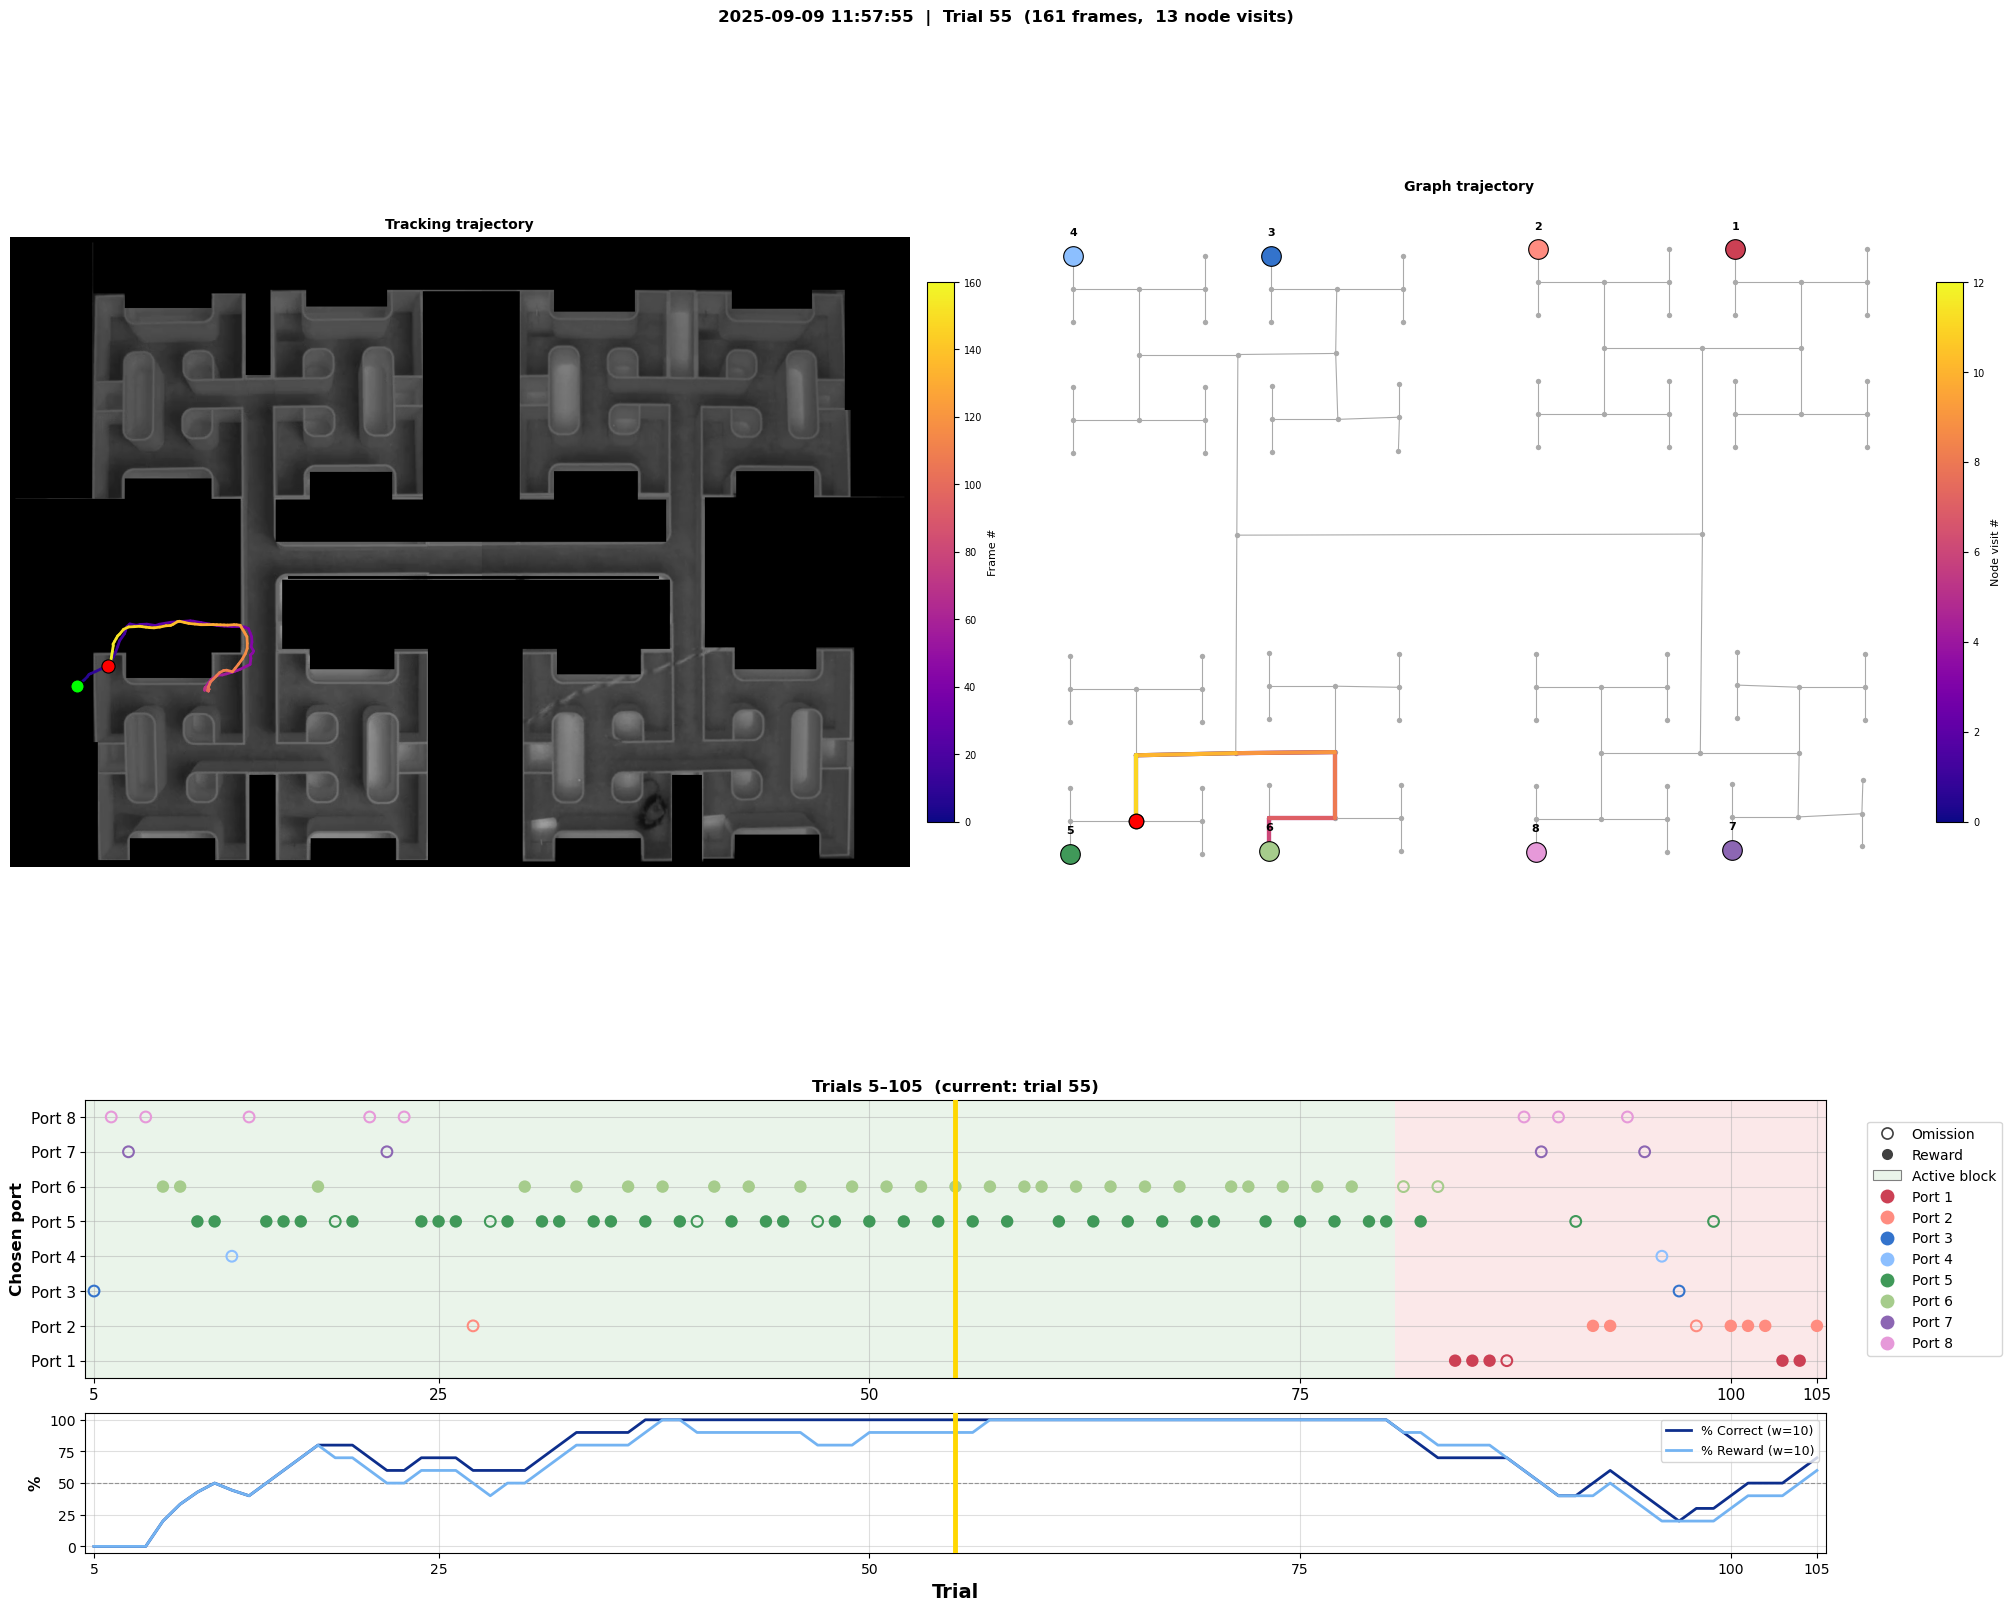

In [3]:
# ── Per-trial trajectory figures for ONE session (change folder_name between runs) ──
folder_name = '09_09_2025'   # ← change this

process_session_trial_figures(folder_name, N=50, rolling_window=10)
print("Done.")

In [ ]:
# ── Quick inline test: full-session raster + 2 trial figures ──────
folder_name = '09_09_2025'
sess_dir    = OUTPUTS_ROOT / folder_name

mat_file    = find_mat_file(folder_name)
mat_data    = sio.loadmat(str(mat_file), simplify_cells=True)
session_data = mat_data['SessionData']
d, t = re.search(r'(\d{8})_(\d{6})', mat_file.name).groups()
session_date = f"{d[:4]}-{d[4:6]}-{d[6:8]}"
session_time = f"{t[:2]}:{t[2:4]}:{t[4:6]}"

# Full-session raster with rolling window
fig = make_reward_raster_real_only(session_data, session_date, session_time,
                                    show_rolling=True, rolling_window=20)
plt.show()

# Per-trial figures (trials 5 and 6)
summary_df   = pd.read_pickle(str(sess_dir / 'summary_df.pkl'))
node_df      = pd.read_pickle(str(sess_dir / 'node_summary_df.pkl'))
maze_mapping = load_maze_mapping(folder_name)
G, centroids = build_session_graph(maze_mapping)
maze_img     = load_maze_image(folder_name)
calib_matrix = load_calibration_matrix(folder_name)
port_map     = get_port_map(folder_name)
_, _, _, port_colors, _ = extract_raster_data(session_data)

for trial_idx in [5, 6]:
    fig = make_trial_context_figure(
        trial_idx, summary_df, node_df, session_data,
        session_date, session_time,
        G, centroids, calib_matrix,
        maze_img, port_map, port_colors,
        N=50, rolling_window=20
    )
    plt.show()